<a href="https://colab.research.google.com/github/KDev-Huh/SoccerBootsRecommendProject-AI/blob/main/Gearmind_%EC%B6%95%EA%B5%AC%ED%99%94_%EC%B6%94%EC%B2%9C_%EB%AA%A8%EB%8D%B8_%ED%95%99%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 상관관계 분석

In [ ]:
from scipy import stats

# ANOVA 수치형 & 범주형 관계 분석

analysis_data = df.fillna(0)
target_col = "BootsName"

# ANOVA 결과를 저장할 리스트
anova_results = []

for col in num_cols:
    # 부츠 타입별로 해당 컬럼의 데이터를 그룹화
    groups = [group[col].values for name, group in analysis_data.groupby(target_col)]

    # *로 리스트를 풀어서 넘겨주면
    # f_stat : 그룹간에 차별화 된것이 있는지
    # p_val : 유연히 차별화 될 확률
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({'Feature': col, 'p-value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('p-value')
print("--- ANOVA 결과 (p-value가 낮을수록 중요) ---")
print(anova_df.head(10))

--- ANOVA 결과 (p-value가 낮을수록 중요) ---
          Feature       p-value
28          LongB  4.716654e-14
9              PS  7.652326e-12
25         UnsTch  4.090288e-10
8             SpG  1.760197e-06
17          Clear  4.968111e-06
24           Disp  5.658858e-06
26           AvgP  6.652245e-06
1   player_height  2.146185e-05
5         Assists  3.745768e-05
0      player_age  5.198830e-05


In [ ]:
from scipy.stats import chi2_contingency

# 카이제곱 범주형 & 범주형 관계 분석

chi2_results = []

# 리스트에서 파생된 컬럼들만 추출 (컬럼명에 _가 포함된 것들)
list_derived_cols = [c for c in analysis_data.columns if '_' in c and c != target_col]

for col in list_derived_cols:
    # 교차표 생성
    # 특정 컬럼을 가지고 있을때의 빈도를 표로 나타냄
    contingency_table = pd.crosstab(analysis_data[col], analysis_data[target_col])

    # 카이제곱 검정
    # chi2 : 관측된 빈도가 관계없는 빈도와 얼마나 차이가 나는지
    # p : p-value
    # ex : 만약 두 컬럼이 관계가 없었다면 나왔을 예상 빈도
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'p-value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p-value')
print("\n--- 카이제곱 검정 결과 (p-value가 낮을수록 중요) ---")
print(chi2_df.head(10))


--- 카이제곱 검정 결과 (p-value가 낮을수록 중요) ---
                                  Feature       p-value
6             player_positions_Goalkeeper  1.417711e-17
38                weaknesses_Long passing  2.869063e-11
25            strengths_Saving long shots  1.581000e-10
41    weaknesses_Saving close range shots  1.479064e-09
24     strengths_Saving close range shots  2.388470e-08
26     strengths_Shot stopping (Reflexes)  2.753826e-08
31            weaknesses_Catching crosses  3.312000e-07
42           weaknesses_Saving long shots  1.232987e-06
2   player_positions_Attacking Midfielder  7.865247e-05
5                player_positions_Forward  1.179370e-04


/tmp/ipython-input-181/1648298122.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi2_df.head(20), x='log_p', y='Feature', palette='magma')


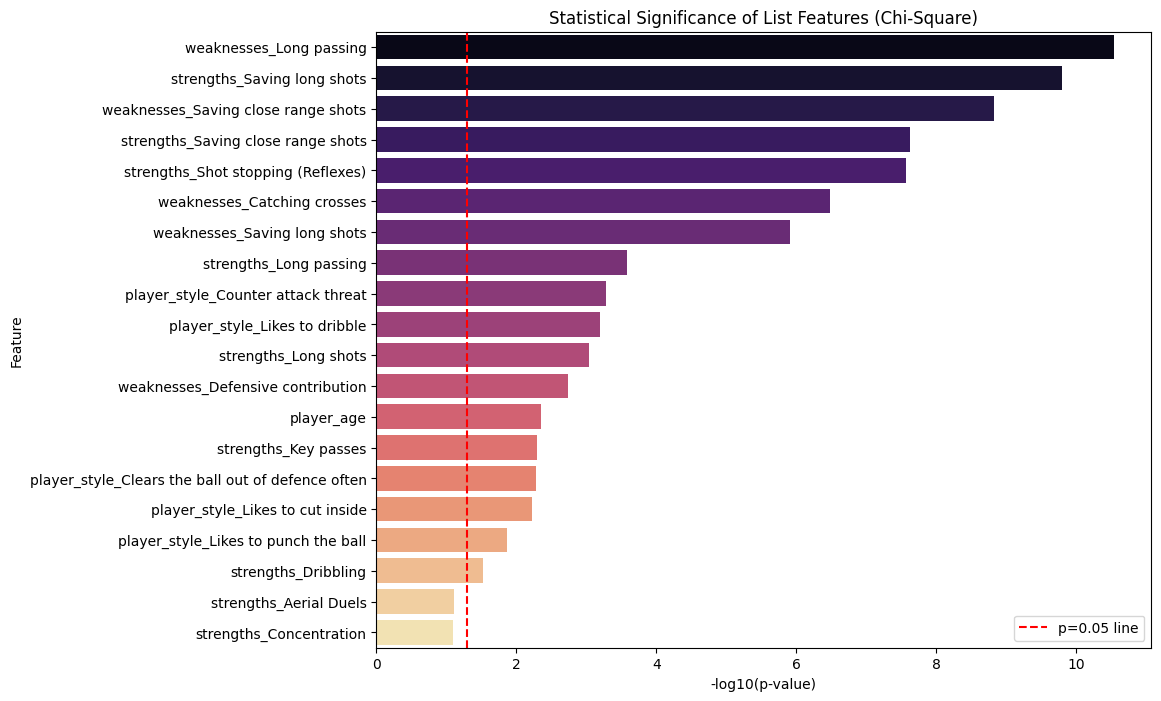

In [ ]:
# p-value에 -log10을 취해 시각화 (값이 클수록 중요함)
# 0.05 미만인 것들은 보통 -log10(p)가 1.3 이상으로 나옵니다.
chi2_df['log_p'] = -np.log10(chi2_df['p-value'].replace(0, 1e-10)) # 0 방지

plt.figure(figsize=(10, 8))
sns.barplot(data=chi2_df.head(20), x='log_p', y='Feature', palette='magma')
plt.axvline(x=-np.log10(0.05), color='r', linestyle='--', label='p=0.05 line')
plt.title("Statistical Significance of List Features (Chi-Square)")
plt.xlabel("-log10(p-value)")
plt.legend()
plt.show()

# 데이터 전처리 및 모델링

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

def multilabel_encode(df, column_name):

    processed_col = df[column_name].apply(
        lambda x: x if isinstance(x, list) else []
    )

    mlb = MultiLabelBinarizer()

    matrix = mlb.fit_transform(processed_col)

    encoded_df = pd.DataFrame(
        matrix,
        columns=[f"{column_name}_{c}" for c in mlb.classes_],
        index=df.index
    )

    df = pd.concat([df, encoded_df], axis=1)
    df = df.drop(columns=[column_name])

    return df

In [ ]:
import re

def clean_player_positions(pos_string):
    """
    "Midfielder (Centre, Left), Forward"
    → ["Midfielder", "Forward"]
    """

    if pd.isna(pos_string):
        return []

    # 1️⃣ 괄호 내용 제거
    no_parentheses = re.sub(r"\(.*?\)", "", pos_string)

    # 2️⃣ 쉼표 기준 분리
    split_positions = no_parentheses.split(",")

    # 3️⃣ 공백 제거 + 빈 값 제거
    cleaned = [p.strip() for p in split_positions if p.strip() != ""]

    return cleaned

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split

paths = [
    "germany-bundesliga-players_boots.csv",
    "premier-league-players_boots.csv",
    "spain-laliga-players_boots.csv"
]

dfs = [pd.read_csv(p) for p in paths]
df = pd.concat(dfs, ignore_index=True)

df["player_age"] = (
    df["player_age"]
    .str.extract(r"(\d+)")   # 숫자만 추출
)

df["player_age"] = pd.to_numeric(df["player_age"], errors="coerce")

df["player_height"] = (
    df["player_height"]
    .str.replace("cm", "", regex=False)  # " cm" 제거
)

df["player_height"] = pd.to_numeric(df["player_height"], errors="coerce")

df["player_positions"] = df["player_positions"].apply(clean_player_positions)

num_cols = [
 'player_age',
 'player_height',
 'Apps',
 'Mins',
 'Goals',
 'Assists',
 'Yel',
 'Red',
 'SpG',
 'PS',
 'AerialsWon',
 'MotM',
 'Rating',
 'Tackles',
 'Inter',
 'Fouls',
 'Offsides',
 'Clear',
 'Drb',
 'Blocks',
 'OwnG',
 'KeyP',
 'Fouled',
 'Off',
 'Disp',
 'UnsTch',
 'AvgP',
 'Crosses',
 'LongB',
 'ThrB'
]
list_cols = [
 'player_positions',
 'strengths',
 'weaknesses',
 'player_style'
]
target = "BootsName"

keep_cols = num_cols + list_cols + [target]

df = df[keep_cols]

## 오버샘플링 후 클래스 그래프 시각화

/tmp/ipykernel_366/1341119043.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=target_col, order=df_filtered[target_col].value_counts().index, palette='viridis')


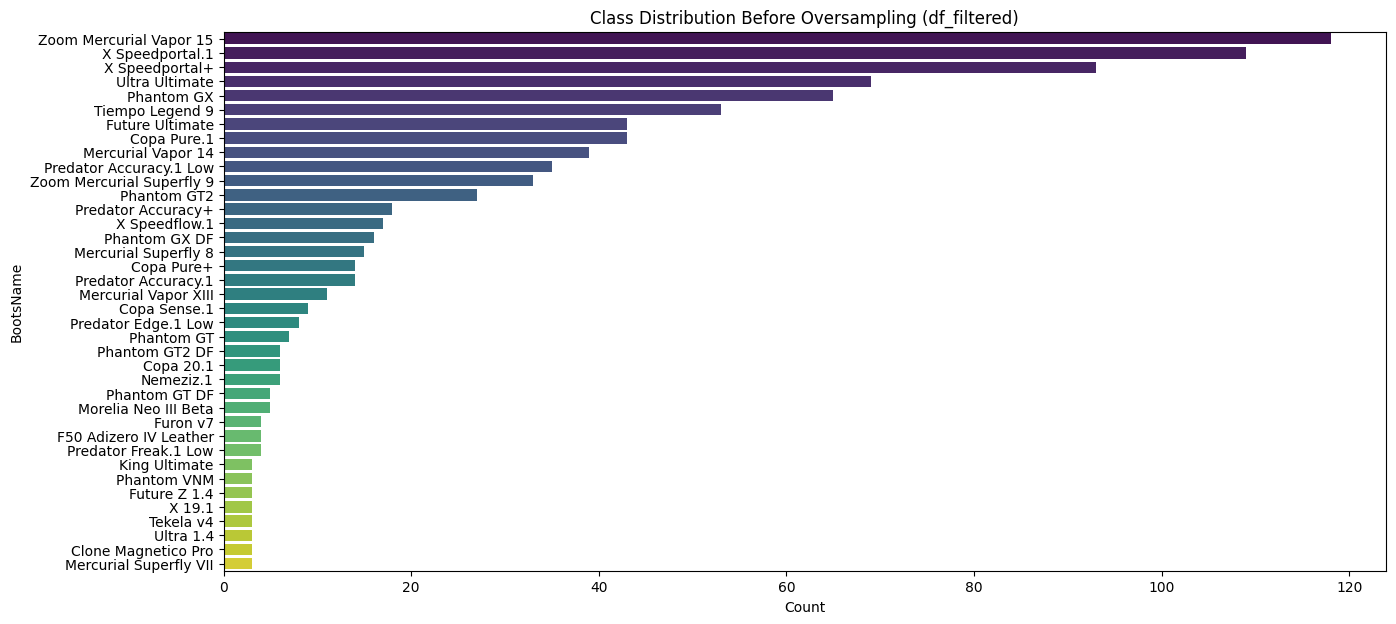

/tmp/ipykernel_366/1341119043.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, y=target_col, order=final_df[target_col].value_counts().index, palette='magma')


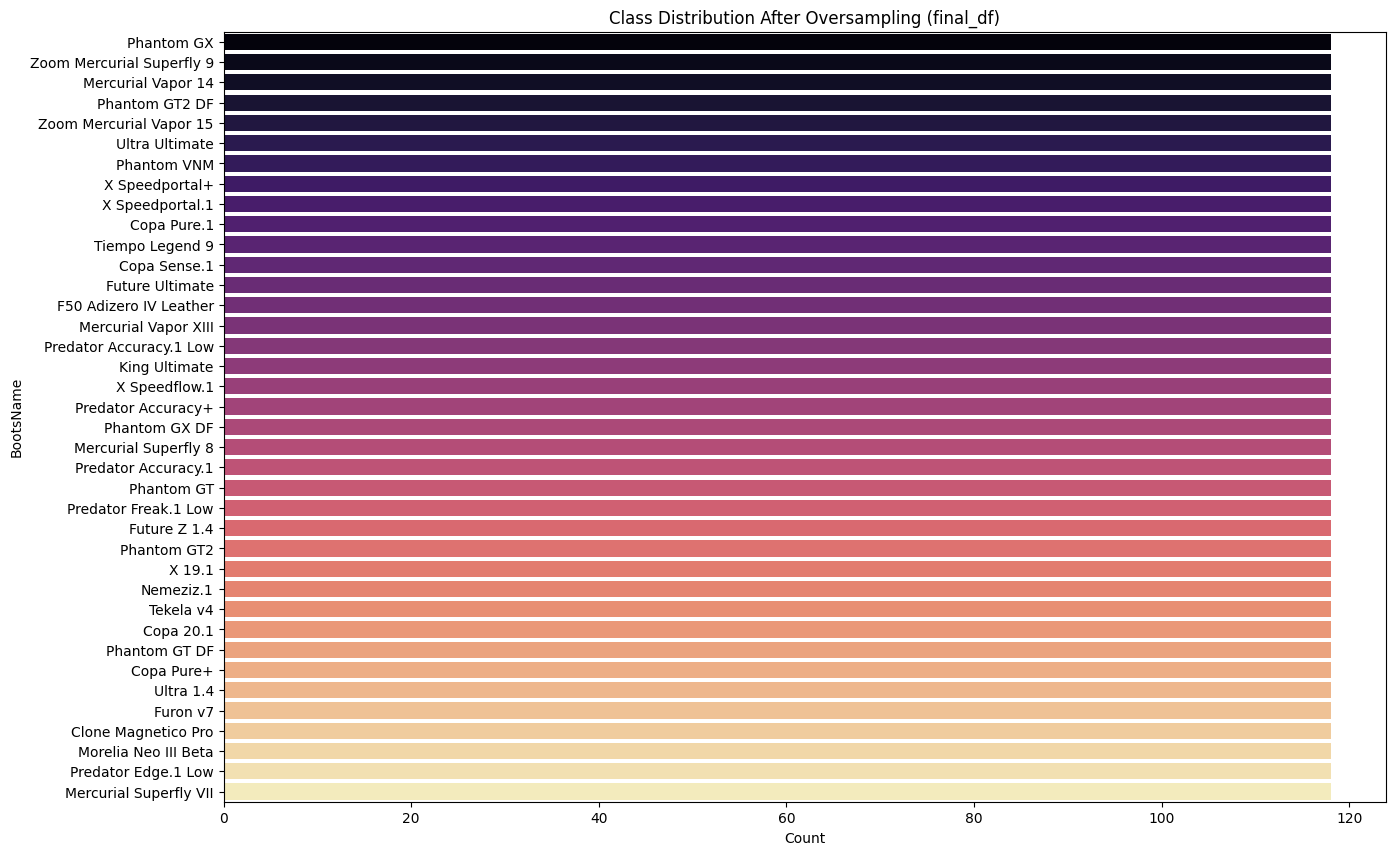

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Before oversampling (using df_filtered)
plt.figure(figsize=(15, 7))
sns.countplot(data=df_filtered, y=target_col, order=df_filtered[target_col].value_counts().index, palette='viridis')
plt.title('Class Distribution Before Oversampling (df_filtered)')
plt.xlabel('Count')
plt.ylabel('BootsName')
plt.show()

# After oversampling (using final_df)
plt.figure(figsize=(15, 10))
sns.countplot(data=final_df, y=target_col, order=final_df[target_col].value_counts().index, palette='magma')
plt.title('Class Distribution After Oversampling (final_df)')
plt.xlabel('Count')
plt.ylabel('BootsName')
plt.show()

## 오버샘플링 비율에 따른 정확도 그래프 시각화

Starting performance evaluation across different oversampling ratios...
  Processing oversampling ratio: 0.1
  Processing oversampling ratio: 0.2
  Processing oversampling ratio: 0.3
  Processing oversampling ratio: 0.4
  Processing oversampling ratio: 0.5
  Processing oversampling ratio: 0.6
  Processing oversampling ratio: 0.7
  Processing oversampling ratio: 0.8
  Processing oversampling ratio: 0.9
  Processing oversampling ratio: 1.0
Evaluation complete.


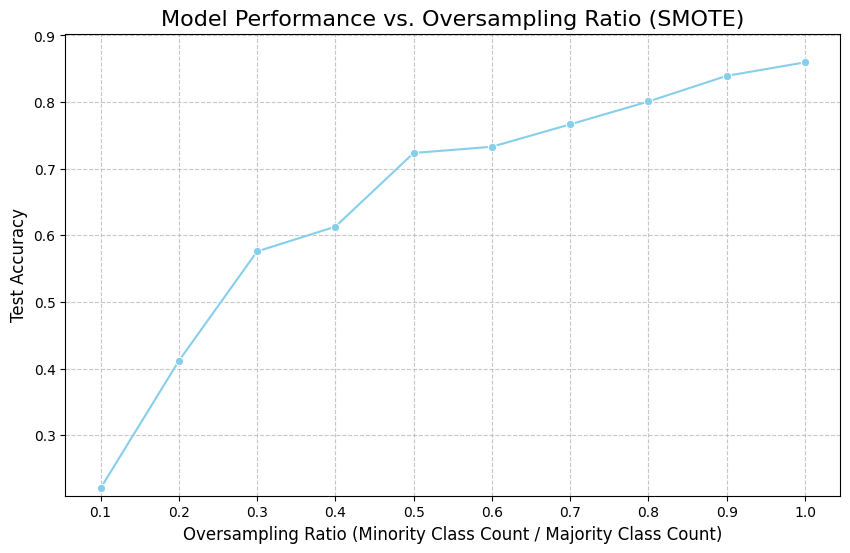

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
import re
import ast # for literal_eval

# --- Re-define clean_player_positions and multilabel_encode functions for robustness ---
# Assuming they are in global scope from previous executed cells. If not, uncomment below.

def clean_player_positions(pos_string):
    if pd.isna(pos_string):
        return []
    no_parentheses = re.sub(r"\(.*\)", "", pos_string)
    split_positions = no_parentheses.split(",")
    cleaned = [p.strip() for p in split_positions if p.strip() != ""]
    return cleaned

def multilabel_encode(df, column_name):
    processed_col = df[column_name].apply(
        lambda x: x if isinstance(x, list) else []
    )
    mlb = MultiLabelBinarizer()
    matrix = mlb.fit_transform(processed_col)
    encoded_df = pd.DataFrame(
        matrix,
        columns=[f"{column_name}_{c}" for c in mlb.classes_],
        index=df.index
    )
    df = pd.concat([df, encoded_df], axis=1)
    df = df.drop(columns=[column_name])
    return df

# --- Re-load and preprocess data to ensure 'df', 'num_cols', 'list_cols', 'target_col' are available ---
paths = [
    "germany-bundesliga-players_boots.csv",
    "premier-league-players_boots.csv",
    "spain-laliga-players_boots.csv"
]
dfs = [pd.read_csv(p) for p in paths]
df = pd.concat(dfs, ignore_index=True)

df["player_age"] = pd.to_numeric(df["player_age"].str.extract(r"(\d+)")[0], errors="coerce")
df["player_height"] = pd.to_numeric(
    df["player_height"].str.replace("cm", "", regex=False), errors="coerce"
)

df["player_positions"] = df["player_positions"].apply(clean_player_positions)

num_cols_raw = [
 'player_age', 'player_height', 'Apps', 'Mins', 'Goals', 'Assists', 'Yel', 'Red', 'SpG', 'PS',
 'AerialsWon', 'MotM', 'Rating', 'Tackles', 'Inter', 'Fouls', 'Offsides', 'Clear', 'Drb', 'Blocks',
 'OwnG', 'KeyP', 'Fouled', 'Off', 'Disp', 'UnsTch', 'AvgP', 'Crosses', 'LongB', 'ThrB'
]
list_cols_raw = [
 'player_positions', 'strengths', 'weaknesses', 'player_style'
]
target_col = "BootsName"

keep_cols = num_cols_raw + list_cols_raw + [target_col]
df = df[keep_cols]

# Filter out classes with less than 3 samples (from 0Eys4qnB8LOj)
df_filtered = df.groupby(target_col).filter(lambda x: len(x) >= 3).reset_index(drop=True)

# Update num_cols and list_cols based on df_filtered's columns
num_cols = [c for c in num_cols_raw if c in df_filtered.columns]
list_cols = [c for c in list_cols_raw if c in df_filtered.columns]

# --- Setup for loop ---
oversampling_ratios = np.arange(0.1, 1.01, 0.1) # Ratios from 0.1 to 1.0
performance_scores = []

# Fit NearestNeighbors once on the original numeric data for list column imputation
# This model helps find similar original samples for synthetic data's list features
nn = NearestNeighbors(n_neighbors=3).fit(df_filtered[num_cols])

# Get the count of the majority class in the original filtered data
majority_class_count = df_filtered[target_col].value_counts().max()

# Use the best parameters from RandomizedSearchCV (from ncz3Z1LwELjj)
best_params = {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1,
               'max_features': 0.3, 'max_depth': 15, 'class_weight': 'balanced', 'bootstrap': True}

print("Starting performance evaluation across different oversampling ratios...")
for ratio in oversampling_ratios:
    print(f"  Processing oversampling ratio: {ratio:.1f}")

    # 1. Define sampling strategy for current ratio
    # For each class, oversample up to 'ratio * majority_class_count'
    strategy = {}
    for cls, count in df_filtered[target_col].value_counts().items():
        strategy[cls] = max(count, int(ratio * majority_class_count)) # Ensure no class is undersampled

    # 2. Apply SMOTE to numeric features
    sm = SMOTE(random_state=42, k_neighbors=2, sampling_strategy=strategy)
    X_num_res, y_res = sm.fit_resample(df_filtered[num_cols], df_filtered[target_col])

    # 3. Impute list columns for resampled data
    resampled_lists = {col: [] for col in list_cols}
    for i in range(len(X_num_res)):
        if i < len(df_filtered): # Original sample retains its original list features
            for col in list_cols:
                resampled_lists[col].append(df_filtered.iloc[i][col])
        else: # Synthetic sample: find list features from a nearest neighbor in original data
            distances, indices = nn.kneighbors(X_num_res.iloc[[i]])
            chosen_idx = np.random.choice(indices[0]) # Randomly pick one neighbor
            for col in list_cols:
                resampled_lists[col].append(df_filtered.iloc[chosen_idx][col])

    # 4. Combine numeric and list features, add target
    current_oversampled_df = pd.concat([X_num_res, pd.DataFrame(resampled_lists)], axis=1)
    current_oversampled_df[target_col] = y_res

    # 5. Encode list columns using multilabel_encode
    processed_df = current_oversampled_df.copy()
    for col in list_cols:
        # Ensure list columns are actual lists (they might be strings if taken from df_filtered directly)
        processed_df[col] = processed_df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        processed_df = multilabel_encode(processed_df, col)

    data = processed_df.drop(columns=[target_col])
    target = processed_df[target_col].to_numpy()

    # 6. Split data into train and test sets (stratified to maintain class proportions)
    train_input, test_input, train_target, test_target = train_test_split(
        data, target, test_size=0.2, random_state=42, stratify=target
    )

    # 7. Train RandomForestClassifier with best parameters
    rf_model = RandomForestClassifier(**best_params)
    rf_model.fit(train_input, train_target)

    # 8. Evaluate and store performance
    accuracy = rf_model.score(test_input, test_target)
    performance_scores.append({'Oversampling Ratio': ratio, 'Test Accuracy': accuracy})

print("Evaluation complete.")
# Convert results to DataFrame for plotting
performance_df = pd.DataFrame(performance_scores)

# --- Plotting the performance graph ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=performance_df, x='Oversampling Ratio', y='Test Accuracy', marker='o', color='skyblue')
plt.title('Model Performance vs. Oversampling Ratio (SMOTE)', fontsize=16)
plt.xlabel('Oversampling Ratio (Minority Class Count / Majority Class Count)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(oversampling_ratios) # Show specific ratio ticks
plt.ylim(performance_df['Test Accuracy'].min() * 0.95, performance_df['Test Accuracy'].max() * 1.05) # Adjust y-axis limits
plt.show()


## 오버샘플링

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE

# 1. 샘플 3개 미만 클래스 삭제
df_filtered = df.groupby('BootsName').filter(lambda x: len(x) >= 3).reset_index(drop=True)
target_col = 'BootsName'

# 2. 수치형과 리스트형 컬럼 분리
num_cols = [c for c in num_cols if c in df_filtered.columns]
list_cols = [c for c in list_cols if c in df_filtered.columns]

# 3. 수치형 데이터에 대해 먼저 SMOTE 적용
sm = SMOTE(random_state=42, k_neighbors=2)
X_num_res, y_res = sm.fit_resample(df_filtered[num_cols], df_filtered[target_col])

# 4. 리스트형 컬럼 채우기 (KNN 방식)
# 원본 데이터의 수치 정보를 바탕으로 이웃을 찾기 위한 모델 생성
nn = NearestNeighbors(n_neighbors=3).fit(df_filtered[num_cols])

resampled_lists = {col: [] for col in list_cols}

for i in range(len(X_num_res)):
    # 만약 새로 생성된 샘플이라면 (원본에 없는 인덱스라면)
    if i >= len(df_filtered):
        # 현재 수치 데이터를 기준으로 원본에서 가장 가까운 이웃 3개를 찾음
        dist, indices = nn.kneighbors(X_num_res.iloc[[i]])
        # 이웃 중 랜덤하게 하나 선택
        chosen_idx = np.random.choice(indices[0])
        for col in list_cols:
            resampled_lists[col].append(df_filtered.iloc[chosen_idx][col])
    else:
        # 원본 데이터는 그대로 유지
        for col in list_cols:
            resampled_lists[col].append(df_filtered.iloc[i][col])

# 5. 하나로 합치기
final_df = pd.concat([X_num_res, pd.DataFrame(resampled_lists)], axis=1)
final_df[target_col] = y_res

print("최종 분포:", Counter(final_df[target_col]))

최종 분포: Counter({'Phantom GX': 118, 'Zoom Mercurial Superfly 9': 118, 'Mercurial Vapor 14': 118, 'Phantom GT2 DF': 118, 'Zoom Mercurial Vapor 15': 118, 'Ultra Ultimate': 118, 'Phantom VNM': 118, 'X Speedportal+': 118, 'X Speedportal.1': 118, 'Copa Pure.1': 118, 'Tiempo Legend 9': 118, 'Copa Sense.1': 118, 'Future Ultimate': 118, 'F50 Adizero IV Leather': 118, 'Mercurial Vapor XIII': 118, 'Predator Accuracy.1 Low': 118, 'King Ultimate': 118, 'X Speedflow.1': 118, 'Predator Accuracy+': 118, 'Phantom GX DF': 118, 'Mercurial Superfly 8': 118, 'Predator Accuracy.1': 118, 'Phantom GT': 118, 'Predator Freak.1 Low': 118, 'Future Z 1.4': 118, 'Phantom GT2': 118, 'X 19.1': 118, 'Nemeziz.1': 118, 'Tekela v4': 118, 'Copa 20.1': 118, 'Phantom GT DF': 118, 'Copa Pure+': 118, 'Ultra 1.4': 118, 'Furon v7': 118, 'Clone Magnetico Pro': 118, 'Morelia Neo III Beta': 118, 'Predator Edge.1 Low': 118, 'Mercurial Superfly VII': 118})


In [ ]:
final_df.to_csv("knn_smote_soccer_boots_data.csv", index=False, encoding='utf-8-sig')

## 모델 학습

In [ ]:
for col in list_cols:
  final_df[col] = final_df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
  final_df = multilabel_encode(final_df, col)

data = final_df.drop(columns=[target_col])
target = final_df[target_col].to_numpy()

train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

# Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 15, 'class_weight': 'balanced', 'bootstrap': True}
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,             # 훈련 점수를 강제로 80%대로 떨어뜨리기 위해 낮게 설정
    min_samples_leaf=1,     # 한 그룹에 최소 15명은 있어야 패턴으로 인정 (개인 암기 방지)
    min_samples_split=2,
    max_features=0.3,
    bootstrap=True,
    random_state=42,
    class_weight='balanced'  # 부츠 타입별 데이터 불균형 해결
)

scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9982575725373843 0.8363589390955039


In [ ]:
rf.fit(train_input, train_target)

RandomForestClassifier(class_weight='balanced', max_depth=15, max_features=0.3,
                       n_estimators=300, random_state=42)

In [ ]:
print(rf.score(test_input, test_target))

0.8450390189520625


## onnx 파일로 export 하기

In [ ]:
!pip install skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 93.8 MB/s eta 0:00:00


In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [('float_input', FloatTensorType([None, 90]))]

options = {id(rf): {'zipmap': False}}

onx = convert_sklearn(rf, initial_types=initial_type, options=options)
with open("rf_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

print("모델이 rf_model.onnx로 저장되었습니다.")

모델이 rf_model.onnx로 저장되었습니다.


# 랜덤 서치로 성능 최적화

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# 1) 모델 (기본 틀)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# 2) 교차검증 방식 (클래스 비율 유지)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) 탐색할 하이퍼파라미터 범위 (과대적합 줄이는 쪽 위주)
param_dist = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [None, 8, 10, 12, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True],
    "class_weight": [None, "balanced"]
}

# 4) 랜덤 탐색 (n_iter 늘릴수록 더 잘 찾지만 시간 증가)
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,                 # 40번 샘플링해서 실험
    scoring="accuracy",        # BootsType은 일단 accuracy로
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

# 5) 탐색 실행
search.fit(data, target)

print("Best CV score:", search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV score: 0.8017391802038543
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 15, 'class_weight': 'balanced', 'bootstrap': True}
